**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 9**
Regresión Logística

---

*   NOMBRE: Eduardo Miguel Paz Calvopiña
*   MATRÍCULA: A00886517

En esta actividad trabajarás con el archivo `breast_cancer.csv`, basado en un conjunto de datos sobre características de tumores mamarios, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar si un tumor es maligno (M) o benigno (B) a partir de medidas extraídas de imágenes de biopsias. Las variables incluidas describen propiedades morfológicas y de textura del tumor y se presentan en tres tipos de medida para cada característica:

* `_mean`: valor promedio de la característica en el tumor
* `_se`: error estándar de la característica (variabilidad de la medición)
* `_worst`: peor valor observado de la característica en el tumor

Los indicadores incluidos son:
* `radius_mean` / `radius_se` / `radius_worst`:	Radio del tumor
* `texture_mean` / `texture_se` / `texture_worst`:	Textura del tumor (desviación estándar de intensidad)
* `perimeter_mean` / `perimeter_se` / `perimeter_worst`:	Perímetro del tumor
* `area_mean` / `area_se` / `area_worst`:	Área del tumor
* `smoothness_mean` / `smoothness_se` / `smoothness_worst`:	Suavidad (irregularidad del borde)
* `compactness_mean` / `compactness_se` / `compactness_worst`:	Compacidad (perimeter^2 / area - 1)
* `concavity_mean` / `concavity_se` / `concavity_worst`:	Concavidad de los contornos
* `concave points_mean` / `concave points_se` / `concave points_worst`:	Número de puntos cóncavos en el contorno
* `symmetry_mean` / `symmetry_se` / `symmetry_worst`:	Simetría del tumor
* `fractal_dimension_mean` / `fractal_dimension_se` / `fractal_dimension_worst`:	Dimensión fractal del contorno (complejidad)
* `diagnosis`: Indica si el tumor es benigno (B) o maligno (M). Es la variable de salida o *target*

In [1]:
# Importar las bibliotecas necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PowerTransformer
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline, Pipeline # Added Pipeline import
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay # Added RocCurveDisplay import
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
DIR = "/content/drive/MyDrive/Colab Notebooks/MIAA/9.1 Aprende | Métricas de evaluación/Acticidad"
os.chdir(DIR)

1. Descarga el archivo: `breast_cancer.csv` y guarda, en un dataframe (`cancer_df`), todos sus registros.
* Haz que la columna `id` sea el nuevo índice.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Verifica si alguna columna contiene valores faltantes.
* Si existen registros duplicados, elimínalos del dataframe y reinicia el índice para que se mantenga consecutivo.
* Obtén las estadísticas descriptivas, separando las variables numéricas (con asimetría y curtosis) y las categóricas.

In [4]:
cancer_df=pd.read_csv('breast_cancer.csv')
cancer_df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [5]:
print("Resumen del DataFrame:")
cancer_df.info()

conteo_tipos = cancer_df.dtypes.value_counts()
print("\nConteo de tipos de datos por columna:")
print(conteo_tipos)

Resumen del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  per

In [6]:
# Verificar valores faltantes
print("\nValores faltantes detectados:")
print(cancer_df.isna().sum())


Valores faltantes detectados:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [7]:
# Eliminar registros duplicados y reiniciar el índice
cancer_df.drop_duplicates(inplace=True)
cancer_df.reset_index(drop=True, inplace=True)

In [8]:
cancer_df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


In [9]:
# Variables numéricas
print("\nEstadísticas descriptivas - Variables Numéricas:")
stats_num = cancer_df.describe().T

stats_num['skewness'] = cancer_df.skew(numeric_only=True)
stats_num['kurtosis'] = cancer_df.kurt(numeric_only=True)
print(stats_num)


Estadísticas descriptivas - Variables Numéricas:
                         count          mean           std          min  \
id                       569.0  3.037183e+07  1.250206e+08  8670.000000   
radius_mean              569.0  1.412729e+01  3.524049e+00     6.981000   
texture_mean             569.0  1.928965e+01  4.301036e+00     9.710000   
perimeter_mean           569.0  9.196903e+01  2.429898e+01    43.790000   
area_mean                569.0  6.548891e+02  3.519141e+02   143.500000   
smoothness_mean          569.0  9.636028e-02  1.406413e-02     0.052630   
compactness_mean         569.0  1.043410e-01  5.281276e-02     0.019380   
concavity_mean           569.0  8.879932e-02  7.971981e-02     0.000000   
concave points_mean      569.0  4.891915e-02  3.880284e-02     0.000000   
symmetry_mean            569.0  1.811619e-01  2.741428e-02     0.106000   
fractal_dimension_mean   569.0  6.279761e-02  7.060363e-03     0.049960   
radius_se                569.0  4.051721e-01  2.77

In [10]:
# Variables categóricas:
print("\nEstadísticas descriptivas - Variables Categóricas:")
print(cancer_df.describe(include=['object']).T)


Estadísticas descriptivas - Variables Categóricas:
          count unique top freq
diagnosis   569      2   B  357


2. Explora relaciones bivariadas en el conjunto de datos mediante gráficos:
* Calcula y visualiza la distribución porcentual de la variable `diagnosis` usando un gráfico de barras, mostrando el porcentaje encima de cada barra. ¿Por qué la distribución de la salida es relevante en un problema de clasificación?
* Genera un pairplot de las variables físicas del conjunto _mean (`radius_mean`, `perimeter_mean`, `area_mean`, `texture_mean`) coloreando por la variable `diagnosis`. ¿Qué relaciones observas entre las variables físicas? ¿Qué diferencias hay entre los tumores benignos y malignos?
* Crea histogramas apilados de las variables morfológicas (`smoothness_mean`, `compactness_mean`, `concavity_mean`, `concave points_mean`, `symmetry_mean`, `fractal_dimension_mean`) coloreando por `diagnosis` para explorar la distribución de cada variable según el tipo de tumor. ¿Alguna variable parece ser un buen discriminador entre las clases?

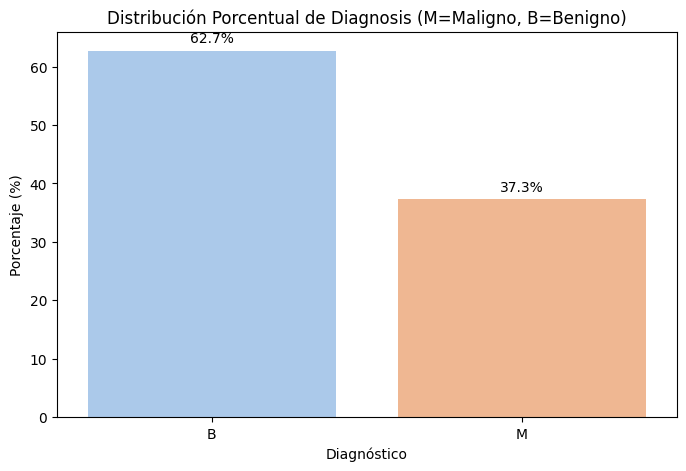

In [11]:
# Cálculo de la distribución porcentual
distribucion = cancer_df['diagnosis'].value_counts(normalize=True) * 100

# Visualización
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=distribucion.index, y=distribucion.values, hue=distribucion.index, palette='pastel', legend=False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points')

plt.title('Distribución Porcentual de Diagnosis (M=Maligno, B=Benigno)')
plt.ylabel('Porcentaje (%)')
plt.xlabel('Diagnóstico')
plt.show()

**RESPUESTA:** En un problema de clasificación, conocer la distribución es fundamental porque los conjuntos de datos sesgados (donde una clase es mucho más frecuente que la otra) pueden engañar al modelo

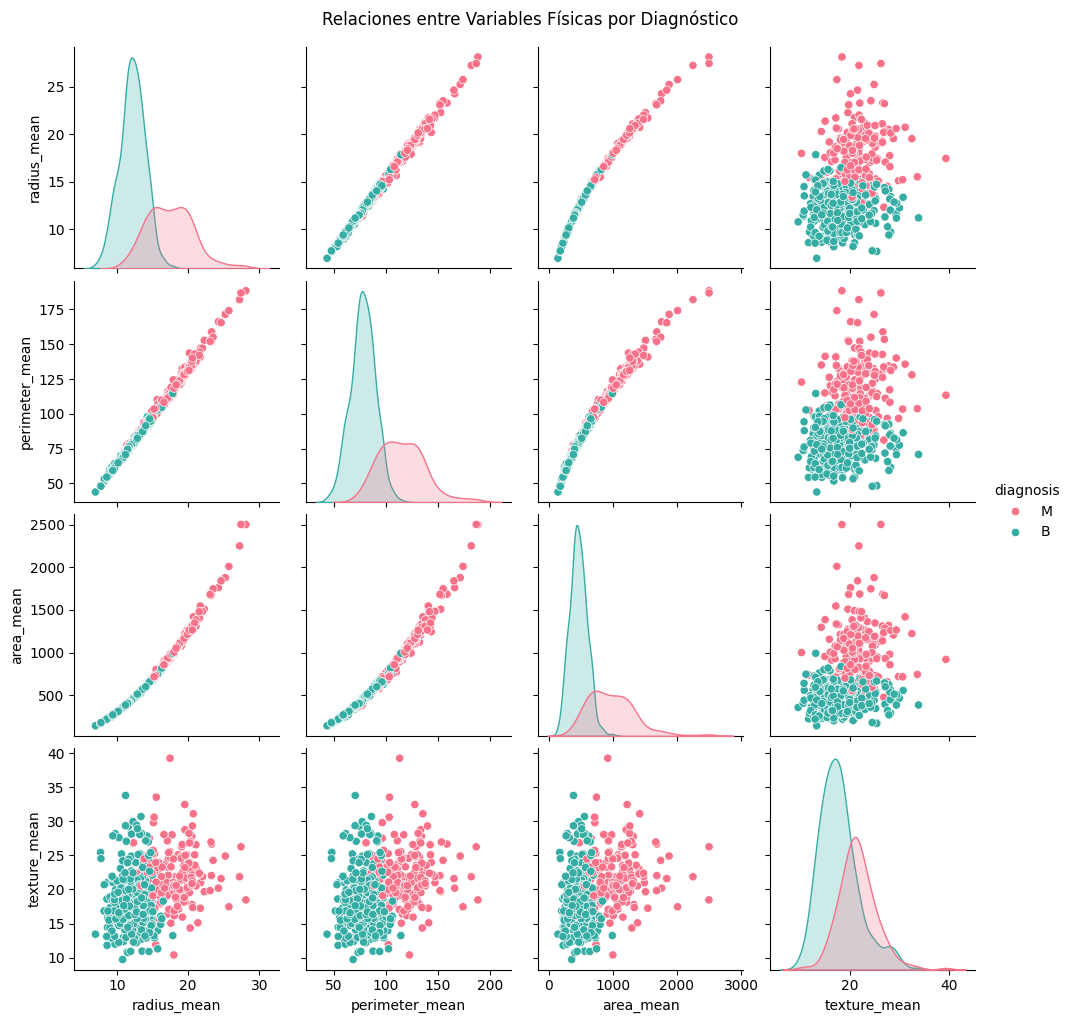

In [12]:
# Variables físicas del conjunto _mean
variables_fisicas = ['radius_mean', 'perimeter_mean', 'area_mean', 'texture_mean']

# Generación del pairplot
sns.pairplot(cancer_df, vars=variables_fisicas, hue='diagnosis', palette='husl', diag_kind='kde')
plt.suptitle('Relaciones entre Variables Físicas por Diagnóstico', y=1.02)
plt.show()

**RESPUESTA:** Existe una correlación positiva muy fuerte y lineal entre radius_mean, perimeter_mean y area_mean, ya que son medidas geométricamente dependientes entre sí. La variable texture_mean muestra una dispersión mayor y una correlación más débil con las medidas de tamaño.

Los tumores malignos (M) tienden a presentar valores significativamente más altos en radio, perímetro y área en comparación con los benignos (B). En las gráficas de densidad de la diagonal, se observa que las distribuciones de los tumores malignos están desplazadas hacia la derecha

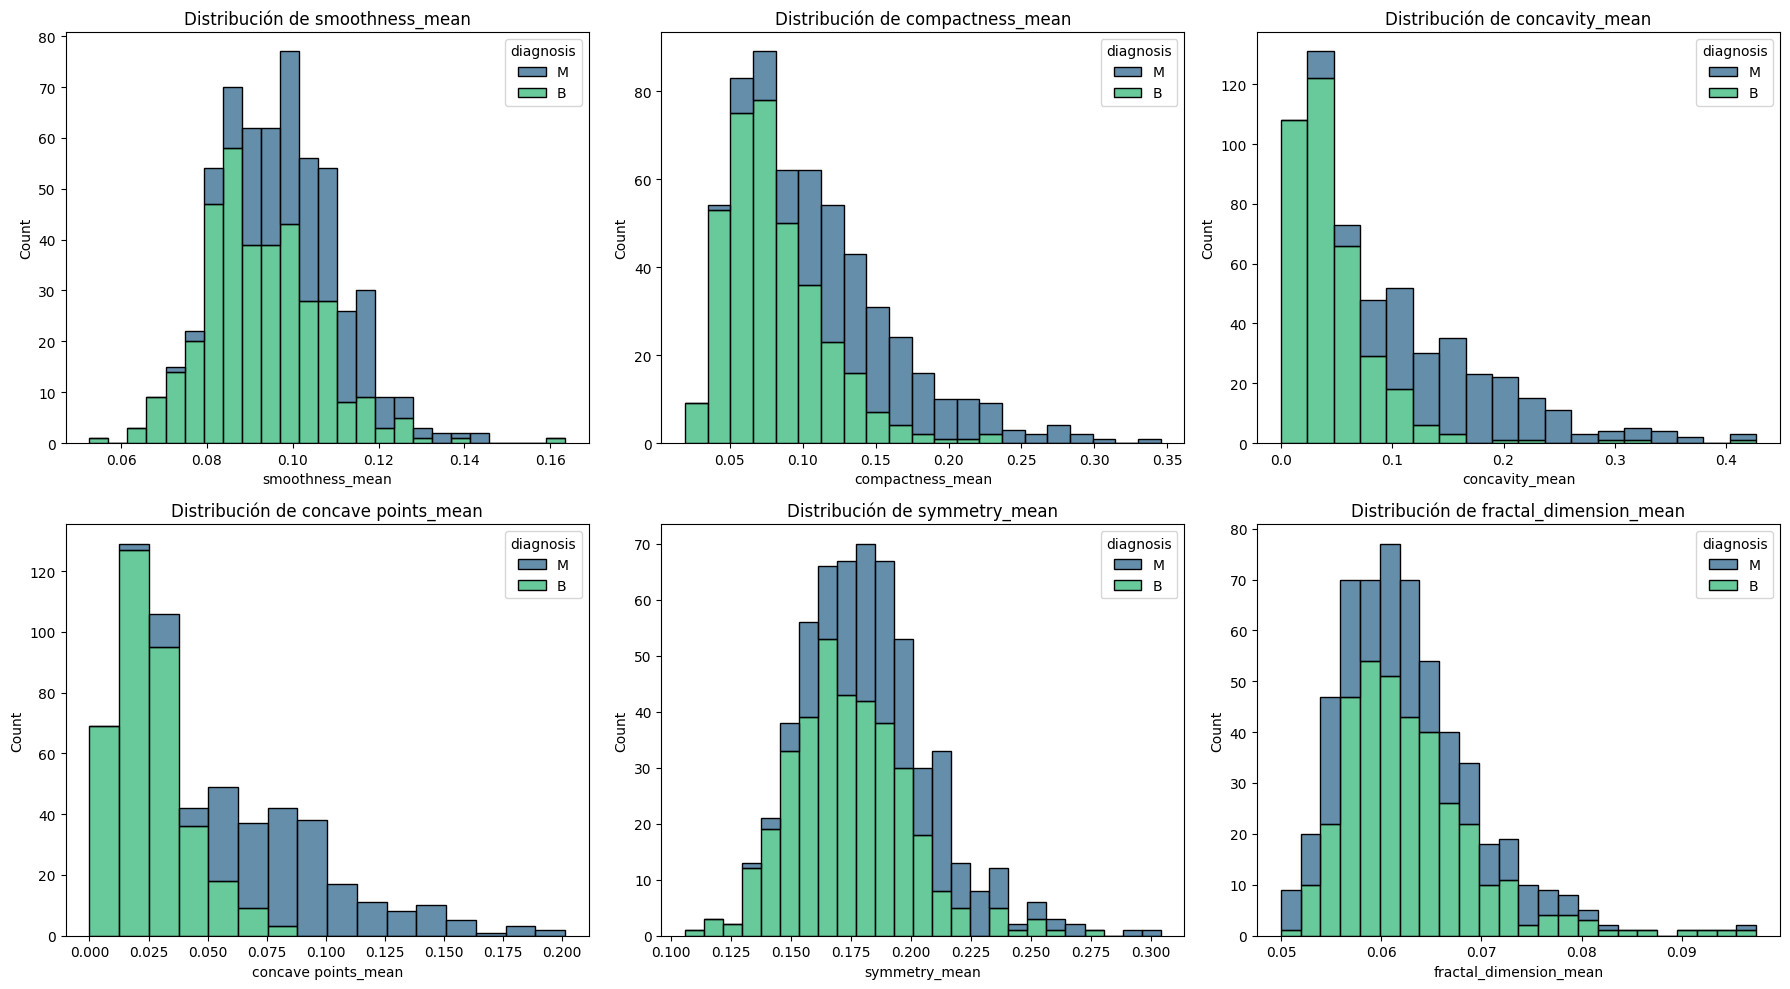

In [13]:
variables_morfologicas = ['smoothness_mean', 'compactness_mean', 'concavity_mean',
                          'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean']

# Creación de histogramas apilados
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, var in enumerate(variables_morfologicas):
    sns.histplot(data=cancer_df, x=var, hue='diagnosis', multiple='stack', ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribución de {var}')

plt.tight_layout()
plt.show()

**RESPUESTA:** Mejor discriminador: Variables como concave points_mean y concavity_mean parecen ser excelentes discriminadores, ya que las distribuciones de tumores benignos y malignos muestran un solapamiento mínimo. Compactness también puede usarse como discriminador

En contraste, smoothness_mean y fractal_dimension_mean presentan mucha intersección entre las clases, lo que sugiere que por sí solas tienen menor poder predictivo para distinguir entre un tumor benigno y uno maligno

3. Antes de realizar el análisis de correlación, crea una copia del dataframe (`cancer_copy`).
* Identifica los pares de variables cuya correlación sea superior a 0.9 e imprímelos. La alta correlación entre las variables del conjunto _mean y _worst es inevitable, ya que las columnas _worst representan esencialmente los valores máximos de las mismas características medidas en _mean. Elimina las columnas _worst para simplificar el análisis.
* Imprime nuevamente los pares con correlación superior a 0.9. Como habías observado previamente, existen relaciones lineales entre `radius`, `perimeter` y `area`, por lo que era esperable encontrar altas correlaciones. De estas tres medidas, ¿cuál mantendrías y por qué? Elimina todas las variables de los otros dos conjuntos.
* Dibuja un mapa de calor con la matriz de correlación para identificar si prevalece alguna correlación relevante. Si eliminas alguna otra variable, justifica tu elección.

In [14]:
cancer_copy = cancer_df.copy()

# Identificar pares con correlación > 0.9
def obtener_pares_alta_corr(df, umbral=0.9):
    corr_matrix = df.corr(numeric_only=True).abs()

    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    pares = [ (column, row, upper.loc[row, column])
             for column in upper.columns
             for row in upper.index
             if upper.loc[row, column] > umbral]
    return pares

print("Pares iniciales con correlación > 0.9:")
for p in obtener_pares_alta_corr(cancer_copy):

    print(f"Pair: ({p[0]}, {p[1]}), Correlation: {p[2]:.4f}")

# Eliminar columnas '_worst'

cols_worst = [col for col in cancer_copy.columns if '_worst' in col]
cancer_copy.drop(columns=cols_worst, inplace=True)
print(f"\nColumnas '_worst' eliminadas: {len(cols_worst)}")

Pares iniciales con correlación > 0.9:
Pair: (perimeter_mean, radius_mean), Correlation: 0.9979
Pair: (area_mean, radius_mean), Correlation: 0.9874
Pair: (area_mean, perimeter_mean), Correlation: 0.9865
Pair: (concave points_mean, concavity_mean), Correlation: 0.9214
Pair: (perimeter_se, radius_se), Correlation: 0.9728
Pair: (area_se, radius_se), Correlation: 0.9518
Pair: (area_se, perimeter_se), Correlation: 0.9377
Pair: (radius_worst, radius_mean), Correlation: 0.9695
Pair: (radius_worst, perimeter_mean), Correlation: 0.9695
Pair: (radius_worst, area_mean), Correlation: 0.9627
Pair: (texture_worst, texture_mean), Correlation: 0.9120
Pair: (perimeter_worst, radius_mean), Correlation: 0.9651
Pair: (perimeter_worst, perimeter_mean), Correlation: 0.9704
Pair: (perimeter_worst, area_mean), Correlation: 0.9591
Pair: (perimeter_worst, radius_worst), Correlation: 0.9937
Pair: (area_worst, radius_mean), Correlation: 0.9411
Pair: (area_worst, perimeter_mean), Correlation: 0.9415
Pair: (area_wo

In [15]:
# 4. Imprimir pares restantes > 0.9
print("\nPares restantes con correlación > 0.9 (tras eliminar _worst):")
for p in obtener_pares_alta_corr(cancer_copy):
    # Corrected print statement
    print(f"Pair: ({p[0]}, {p[1]}), Correlation: {p[2]:.4f}")


Pares restantes con correlación > 0.9 (tras eliminar _worst):
Pair: (perimeter_mean, radius_mean), Correlation: 0.9979
Pair: (area_mean, radius_mean), Correlation: 0.9874
Pair: (area_mean, perimeter_mean), Correlation: 0.9865
Pair: (concave points_mean, concavity_mean), Correlation: 0.9214
Pair: (perimeter_se, radius_se), Correlation: 0.9728
Pair: (area_se, radius_se), Correlation: 0.9518
Pair: (area_se, perimeter_se), Correlation: 0.9377


**RESPUESTA:** Mantener radius_mean. La razón es que el perímetro y el área son funciones directas del radio; por lo tanto, radius es la medida fundamental

In [16]:
# Eliminar Perimeter y Area (manteniendo Radius)
cols_a_eliminar = [col for col in cancer_copy.columns if 'perimeter' in col or 'area' in col]
cancer_copy.drop(columns=cols_a_eliminar, inplace=True)
print(f"Variables de perímetro y área eliminadas: {cols_a_eliminar}")

Variables de perímetro y área eliminadas: ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se']


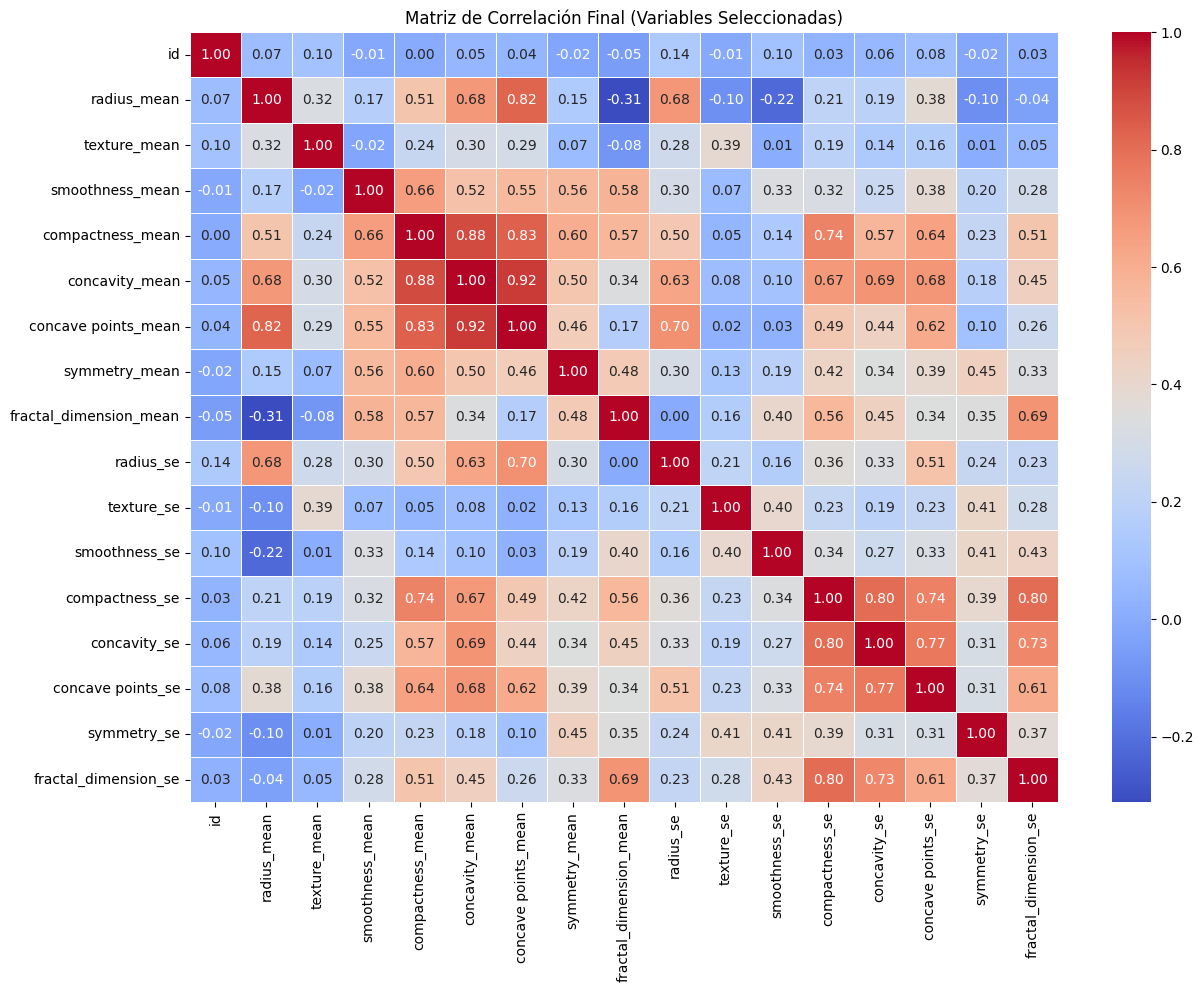

In [17]:
# Mapa de calor final
plt.figure(figsize=(14, 10))
sns.heatmap(cancer_copy.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación Final (Variables Seleccionadas)')
plt.show()

**JUSTIFICACION:** Sigue existiendo una alta correlación entre concavity_mean y concave points_means. voy a mantener concave points_mean ya que el análisis visual muestra un mejor desempeño como discriminador por su distribución.

In [18]:
# Eliminación de variable redundante (correlación > 0.9)
cancer_copy.drop(columns=['concavity_mean'], inplace=True)

print("Variable 'concavity_mean' eliminada.")
print("Columnas actuales en cancer_copy:", cancer_copy.columns.tolist())

Variable 'concavity_mean' eliminada.
Columnas actuales en cancer_copy: ['id', 'diagnosis', 'radius_mean', 'texture_mean', 'smoothness_mean', 'compactness_mean', 'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean', 'radius_se', 'texture_se', 'smoothness_se', 'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se', 'fractal_dimension_se']


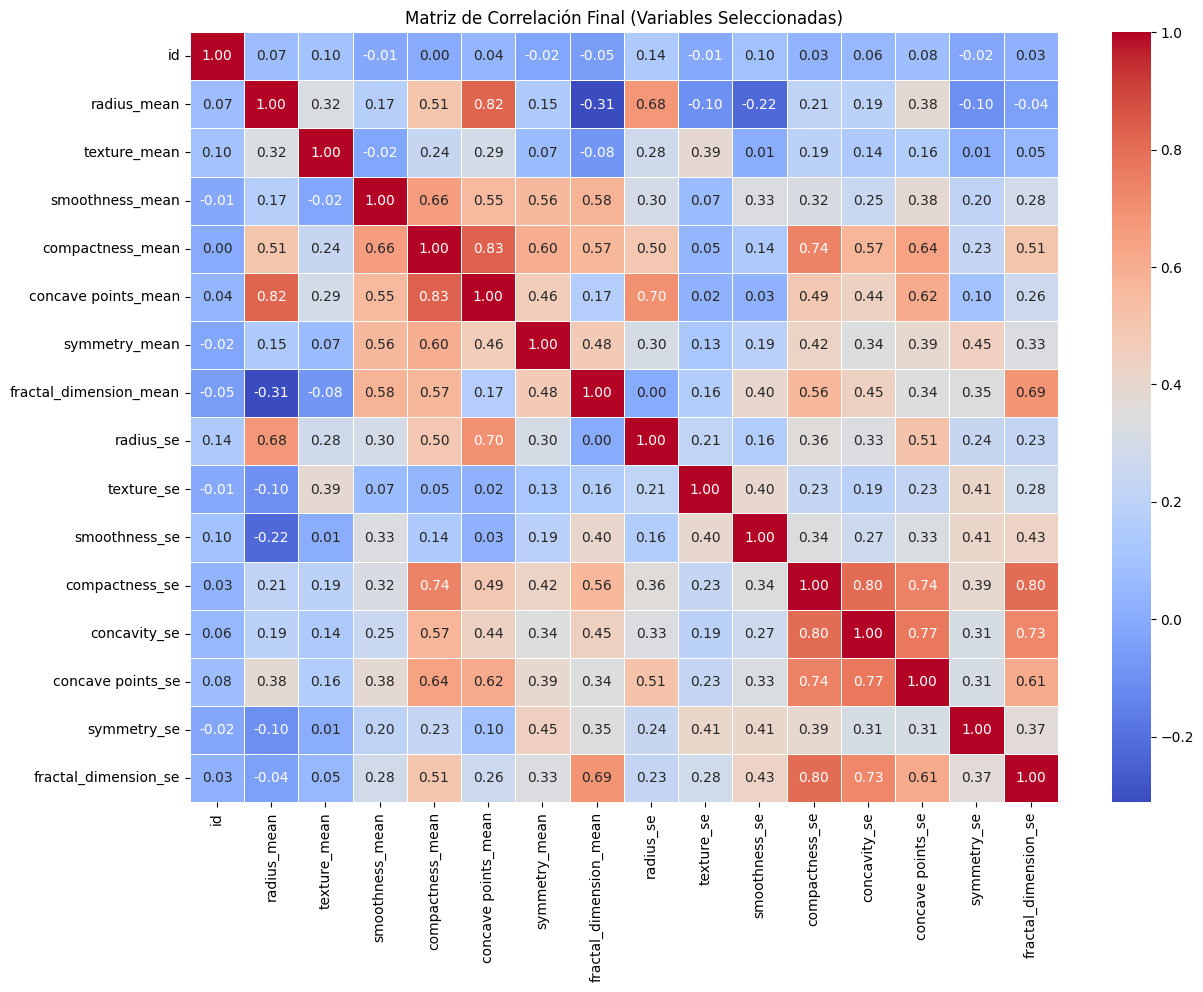

In [19]:
plt.figure(figsize=(14, 10))
sns.heatmap(cancer_copy.corr(numeric_only=True), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación Final (Variables Seleccionadas)')
plt.show()

4. Separa las variables predictoras `X` de la variable de salida `y`, usando el dataframe original `cancer_df` (la eliminación de variables correlacionadas se integrará en el pipeline).
* Codifica `diagnosis` como 0 (Benigno) y 1 (Maligno).
* Divide el conjunto de datos en entrenamiento y prueba (80:20), usando `random_state=1` para garantizar reproducibilidad.
* Para evaluar los modelos que se construirán, define una función llamada `evaluate_model` que reciba los valores reales y las predicciones e imprima las métricas de recall, precisión y exactitud (accuracy).

In [20]:
# Separar variables predictoras X de la variable de salida y
X = cancer_df.drop(columns=['diagnosis'])
y = cancer_df['diagnosis']

In [21]:
# Codificar diagnosis como 0 (Benigno) y 1 (Maligno)
y = y.map({'B': 0, 'M': 1})

In [22]:
# Dividir el conjunto de datos en entrenamiento y prueba (80:20)
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=1)

In [23]:
# 4. Definir la función evaluate_model
def evaluate_model(y_real, y_pred):

    recall = recall_score(y_real, y_pred)
    precision = precision_score(y_real, y_pred)
    accuracy = accuracy_score(y_real, y_pred)

    print(f"Métricas de Evaluación:")
    print(f"  Recall:    {recall:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Accuracy:  {accuracy:.4f}")

# Verificación de la división
print(f"Conjunto de entrenamiento: {Xtrain.shape} registros")
print(f"Conjunto de prueba: {Xtest.shape} registros")

Conjunto de entrenamiento: (455, 31) registros
Conjunto de prueba: (114, 31) registros


5. Prepara un transformador denominado `preprocessing`, usando ColumnTransformer, para borrar las columnas altamente correlacionadas (identificadas en el ejercicio 3) Asegúrate de incluir el parámetro `remainder='passthrough'` para mantener el resto de las variables.
* Crea un pipeline que integre el transformador y regresión logística para  entrenar un modelo.
* Evalúa el desempeño del modelo en el conjunto de prueba empleando la función `evaluate_model`.
* Integra los resultados en un dataframe que contenga el nombre del modelo (*Correlation_Clean*) y una columna para cada métrica calculada.

In [24]:
# Preparar el transformador 'preprocessing'
# Identificamos las columnas a borrar
cols_worst = [col for col in X.columns if '_worst' in col]
cols_fisicas_redundantes = ['perimeter_mean', 'area_mean']
cols_morfologicas_redundantes = ['concavity_mean']

cols_to_drop = cols_worst + cols_fisicas_redundantes + cols_morfologicas_redundantes

preprocessing = ColumnTransformer(transformers=[('drop_cols', 'drop', cols_to_drop)],
    remainder='passthrough', force_int_remainder_cols=False )

In [25]:
# Crear el Pipeline
model_pipeline = Pipeline(steps=[
    ('prep', preprocessing),
    ('logistic', LogisticRegression(max_iter=10000))])
# Entrenar el modelo
model_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('drop_cols', 'drop',
                                                  ['radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'concavity_mean'])])),
                ('logistic', LogisticRegression(max_iter=10000))])

In [26]:
# Evaluar el desempeño
y_pred = model_pipeline.predict(Xtest)

print("Evaluación del modelo: Correlation_Clean")
evaluate_model(ytest, y_pred)

Evaluación del modelo: Correlation_Clean
Métricas de Evaluación:
  Recall:    0.5714
  Precision: 0.8000
  Accuracy:  0.7895


In [27]:
# Integrar resultados en un DataFrame
metricas = {
    'Modelo': ['Correlation_Clean'],
    'Recall': [recall_score(ytest, y_pred)],
    'Precision': [precision_score(ytest, y_pred)],
    'Accuracy': [accuracy_score(ytest, y_pred)]
}

res_df = pd.DataFrame(metricas)
display(res_df)

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.571429,0.8,0.789474


6. Una alternativa para reducir la multicolinealidad es el análisis de componentes principales. Construye un pipeline que incluya escalado estándar, PCA y regresión logística, manteniendo el número mínimo de componentes principales que expliquen al menos el 90% de la varianza.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Standard_PCA*.
* ¿Cuántos componentes principales se emplearon?

In [28]:
# Pipeline
pca_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.90)),
    ('logistic', LogisticRegression(max_iter=10000))
])

In [29]:
# Entrenar el modelo
pca_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=0.9)),
                ('logistic', LogisticRegression(max_iter=10000))])

In [30]:
# Evaluar el desempeño en el conjunto de prueba
y_pred_pca = pca_pipeline.predict(Xtest)

print("Evaluación del modelo: Standard_PCA")
evaluate_model(ytest, y_pred_pca)

Evaluación del modelo: Standard_PCA
Métricas de Evaluación:
  Recall:    0.9286
  Precision: 1.0000
  Accuracy:  0.9737


In [31]:
# Dataframe de resultados
from sklearn.metrics import recall_score, precision_score, accuracy_score

nueva_metrica = pd.DataFrame({
    'Modelo': ['Standard_PCA'],
    'Recall': [recall_score(ytest, y_pred_pca)],
    'Precision': [precision_score(ytest, y_pred_pca)],
    'Accuracy': [accuracy_score(ytest, y_pred_pca)]
})

res_df = pd.concat([res_df, nueva_metrica], ignore_index=True)
display(res_df)

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.571429,0.8,0.789474
1,Standard_PCA,0.928571,1.0,0.973684


In [32]:
# Componentes principales empleados
n_pcs = pca_pipeline.named_steps['pca'].n_components_
print(f"\nComponentes principales empleados para explicar el 90% de la varianza: {n_pcs}")



Componentes principales empleados para explicar el 90% de la varianza: 8


7. Como intento de mejorar las métricas del modelo, y dado que todas las variables presentan sesgo, aplica una normalización utilizando Yeo-Johnson. Para ello:
* Crea un pipeline que integre el transformador `preprocessing`, una transformación Yeo-Johnson y regresión logística.
* Entrena el modelo utilizando el conjunto de entrenamiento y evalúalo en el conjunto de prueba.
* Añade los valores de las métricas obtenidas al dataframe de resultados, utilizando como nombre del modelo *Correlation_Yeo*.

In [33]:
# Pipeline
yeo_pipeline = Pipeline(steps=[
    ('prep', preprocessing),
    ('yeo', PowerTransformer(method='yeo-johnson', standardize=True)),
    ('logistic', LogisticRegression(max_iter=10000))
])

In [34]:
# Entrenar el modelo
yeo_pipeline.fit(Xtrain, ytrain)

Pipeline(steps=[('prep',
                 ColumnTransformer(force_int_remainder_cols=False,
                                   remainder='passthrough',
                                   transformers=[('drop_cols', 'drop',
                                                  ['radius_worst',
                                                   'texture_worst',
                                                   'perimeter_worst',
                                                   'area_worst',
                                                   'smoothness_worst',
                                                   'compactness_worst',
                                                   'concavity_worst',
                                                   'concave points_worst',
                                                   'symmetry_worst',
                                                   'fractal_dimension_worst',
                                                   'perimeter_mean',
                                                   'area_mean',
                                                   'concavity_mean'])])),
                ('yeo', PowerTransformer()),
                ('logistic', LogisticRegression(max_iter=10000))])

In [35]:
y_pred_yeo = yeo_pipeline.predict(Xtest)

print("Evaluación del modelo: Correlation_Yeo")
evaluate_model(ytest, y_pred_yeo)

Evaluación del modelo: Correlation_Yeo
Métricas de Evaluación:
  Recall:    0.9524
  Precision: 1.0000
  Accuracy:  0.9825


In [36]:
# Dataframe comparativo
nueva_metrica_yeo = pd.DataFrame({
    'Modelo': ['Correlation_Yeo'],
    'Recall': [recall_score(ytest, y_pred_yeo)],
    'Precision': [precision_score(ytest, y_pred_yeo)],
    'Accuracy': [accuracy_score(ytest, y_pred_yeo)]
})

res_df = pd.concat([res_df, nueva_metrica_yeo], ignore_index=True)
display(res_df)

,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.571429,0.8,0.789474
1,Standard_PCA,0.928571,1.0,0.973684
2,Correlation_Yeo,0.952381,1.0,0.982456


8. Del modelo anterior, obtén los nombres de los predictores empleados. ¿Cuántos son?
* Revisa los coeficientes del modelo de regresión logística y analiza su magnitud para identificar las variables 10 más influyentes.
* Grafícalas en un barplot horizontal, mostrando el valor del coeficiente y respetando su signo.

In [37]:
feature_names = yeo_pipeline.named_steps['prep'].get_feature_names_out()
n_predictores = len(feature_names)

print(f"Nombres de los predictores: {feature_names}")
print(f" {n_predictores} predictores.")

Nombres de los predictores: ['remainder__id' 'remainder__radius_mean' 'remainder__texture_mean'
 'remainder__smoothness_mean' 'remainder__compactness_mean'
 'remainder__concave points_mean' 'remainder__symmetry_mean'
 'remainder__fractal_dimension_mean' 'remainder__radius_se'
 'remainder__texture_se' 'remainder__perimeter_se' 'remainder__area_se'
 'remainder__smoothness_se' 'remainder__compactness_se'
 'remainder__concavity_se' 'remainder__concave points_se'
 'remainder__symmetry_se' 'remainder__fractal_dimension_se']
 18 predictores.


In [38]:
# Coeficientes del modelo de regresión logística
coeficientes = yeo_pipeline.named_steps['logistic'].coef_

In [39]:
importancia_df = pd.DataFrame({
    'Predictor': feature_names,
    'Coeficiente': coeficientes[0], # Flatten the 2D array to 1D
    'Abs_Coef': np.abs(coeficientes[0]) # Usamos valor absoluto para identificar "influencia" total [4]
})
top_10_influyentes = importancia_df.sort_values(by='Abs_Coef', ascending=False).head(10)

print(top_10_influyentes[['Predictor', 'Coeficiente']].to_string(index=False))
print("-" * 50)

                     Predictor  Coeficiente
remainder__concave points_mean     2.386090
       remainder__texture_mean     1.911253
            remainder__area_se     1.253188
        remainder__radius_mean     1.059452
       remainder__concavity_se     1.000270
      remainder__symmetry_mean     0.782883
        remainder__symmetry_se    -0.738135
     remainder__compactness_se    -0.724279
   remainder__compactness_mean     0.623041
         remainder__texture_se    -0.616016
--------------------------------------------------


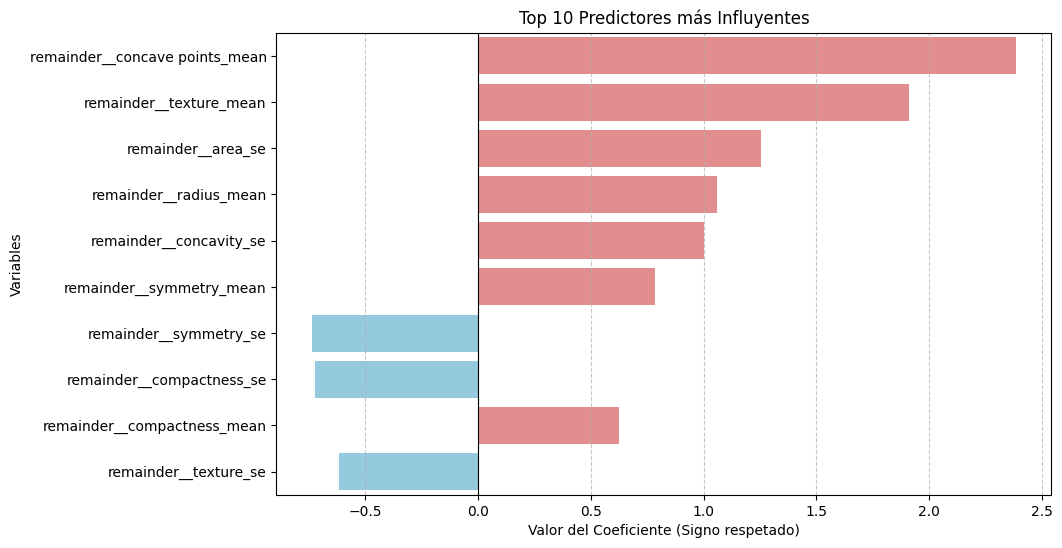

In [40]:
#barplot horizontal
plt.figure(figsize=(10, 6))
colors = ['lightcoral' if c > 0 else 'skyblue' for c in top_10_influyentes['Coeficiente']]

sns.barplot(
    x='Coeficiente',
    y='Predictor',
    data=top_10_influyentes,
    palette=colors,
    hue='Predictor',
    legend=False
)

plt.axvline(0, color='black', linestyle='-', linewidth=0.8) # Línea de referencia en cero
plt.title('Top 10 Predictores más Influyentes')
plt.xlabel('Valor del Coeficiente (Signo respetado)')
plt.ylabel('Variables')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

9. Imprime el dataframe de resultados.
* Dibuja la matriz de confusión del mejor modelo. ¿Qué significa cada valor en ella?
* Dibuja la curva ROC del mismo modelo y describe lo que indica sobre su capacidad para distinguir entre clases.

In [41]:
# Tabla comparativa
print("Resumen de Métricas por Modelo:")
display(res_df)

mejor_modelo = yeo_pipeline

Resumen de Métricas por Modelo:


,Modelo,Recall,Precision,Accuracy
0,Correlation_Clean,0.571429,0.8,0.789474
1,Standard_PCA,0.928571,1.0,0.973684
2,Correlation_Yeo,0.952381,1.0,0.982456


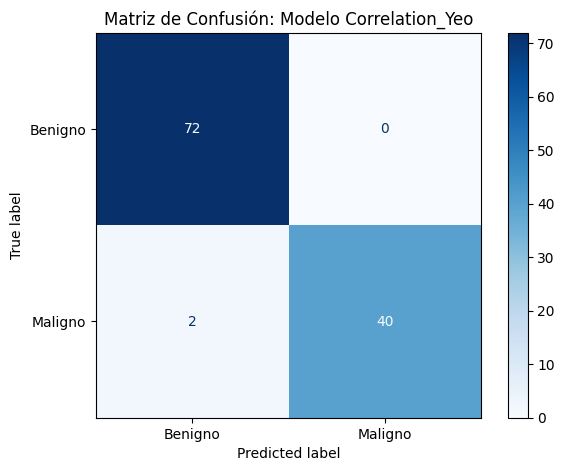

In [42]:
# Generar la matriz
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(ytest, mejor_modelo.predict(Xtest),
                                        display_labels=['Benigno', 'Maligno'],
                                        cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión: Modelo Correlation_Yeo')
plt.show()

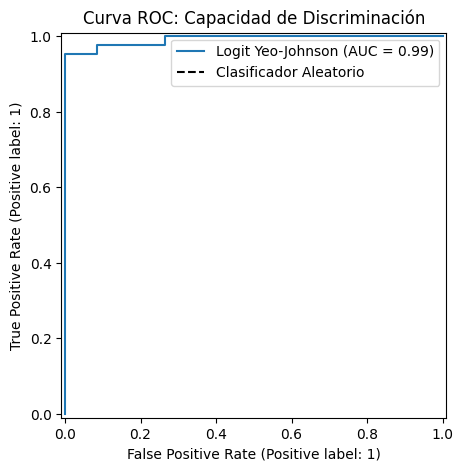

In [43]:
# Para la curva ROC se usan las probabilidades de la clase positiva
y_probabilidades = mejor_modelo.predict_proba(Xtest)[:, 1]

fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(ytest, y_probabilidades, ax=ax, name='Logit Yeo-Johnson')
plt.plot([9], 'k--', label='Clasificador Aleatorio') # Línea de referencia [8]
plt.title('Curva ROC: Capacidad de Discriminación')
plt.legend()
plt.show()

**RESPUESTA:** La curva se acerca a la esquina superior izquierda, esto indica que el modelo logra un alto recall con muy pocos falsos positivos.

AUC = 0.99 mientras más se acerque a 1 indica que el modelo tiene buena capacidad para distinguir entre tumor maligno y benigno.


10. Grafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
* ¿Cuál es el umbral (*threshold*) por defecto que utiliza scikit-learn para convertir probabilidades en predicciones binarias?
* En un modelo de diagnóstico médico, ¿cuál consideras que es la métrica más importante?
* ¿Cómo cambiarías (disminuir / aumentar) el *threshold*? ¿Por qué?

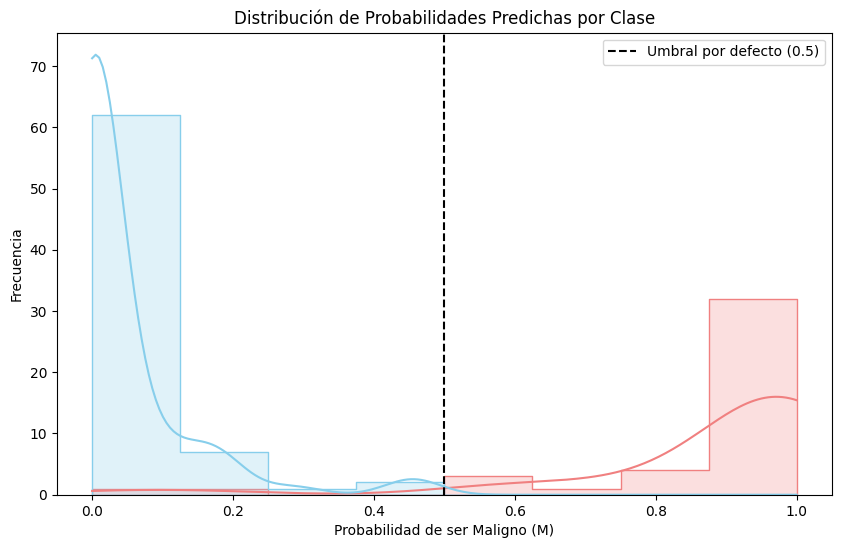

In [44]:
# rafica la distribución de las probabilidades predichas por clase utilizando histogramas superpuestos, diferenciando la clase Benigno (B) y la clase Maligno (M) con colores.
y_probs = yeo_pipeline.predict_proba(Xtest)[:, 1]

probs_df = pd.DataFrame({
    'Probabilidad': y_probs,
    'Clase_Real': ytest.map({0: 'Benigno (B)', 1: 'Maligno (M)'})
})

plt.figure(figsize=(10, 6))
sns.histplot(data=probs_df, x='Probabilidad', hue='Clase_Real',
             element='step', kde=True, palette={'Benigno (B)': 'skyblue', 'Maligno (M)': 'lightcoral'})

plt.axvline(x=0.5, color='black', linestyle='--', label='Umbral por defecto (0.5)')
plt.title('Distribución de Probabilidades Predichas por Clase')
plt.xlabel('Probabilidad de ser Maligno (M)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

**Cuál es el umbral (threshold) por defecto?**
El umbral de decisión por defecto en scikit-learn para problemas de clasificación binaria es 0.5

**¿Cuál es la métrica más importante en un diagnóstico médico?**
En el diagnóstico de cáncer, la métrica más importante es el Recall (Sensibilidad). El objetivo primordial es minimizar los Falsos Negativos (FN)

¿Cómo y por qué cambiarías el threshold?
Bajaría el threshold. Al bajar el umbral, el modelo es más sensible y puede clasificar a un paciente como Maligno aunque tenga una probabilidad menor al 50% pero aumentaría el recall para detectar el error tipo II que es el que queremos minimizar

In [45]:
# 1. Obtener las probabilidades de la clase positiva (Maligno) para el conjunto de prueba
# Usamos el pipeline del modelo Yeo-Johnson
y_probs_yeo = yeo_pipeline.predict_proba(Xtest)[:, 1]

# 2. Definir el nuevo umbral de decisión
threshold = 0.1

# 3. Convertir probabilidades en predicciones binarias usando el nuevo umbral
# Si la probabilidad es >= 0.4, se asigna 1 (Maligno), de lo contrario 0 (Benigno)
y_pred_custom = (y_probs_yeo >= threshold).astype(int)

# 4. Evaluar el desempeño con el nuevo umbral
print(f"Evaluación del modelo Correlation_Yeo con Threshold = {threshold}:")
evaluate_model(ytest, y_pred_custom)

Evaluación del modelo Correlation_Yeo con Threshold = 0.1:
Métricas de Evaluación:
  Recall:    0.9762
  Precision: 0.8039
  Accuracy:  0.9035


Para subir el recall se necesita poner un threshold de 0.1 castigando demasiado al modelo